# Maths Lab F — Special Functions & Beams

!!! info "Before you start"
    **Prerequisites:** Ch 4 (Antennas & Receivers) · **Appendix · Maths Lab** · **~45 min** · **Intermediate**

*An appendix reference Lab for the `jansky` course.*

A handful of named functions turn up again and again across radio astronomy: the
**sinc**, the **Gaussian**, the **Airy pattern** (and its Bessel $J_1$), and the
**power law**. They are not exotic — each one is the answer to a question we keep
asking ("what does a finite aperture do?", "what does a tapered beam look like?",
"how does flux fall off with frequency?") — and once you can recognise them on
sight, large chunks of the course stop looking like new material.

This Lab consolidates them in one place. It is a *reference*: read it once for the
intuition, then come back to it whenever a sinc or an Airy ring shows up in another
chapter. Everything here is the companion to **§8 "A few special functions"** of the
[Mathematical Preliminaries](../docs/math-preliminaries.md); this notebook is the
runnable version of that section.

**Learning goals.** By the end you will be able to:

- recognise the **sinc** as the Fourier transform of a rectangle, read off its first
  null and $-13.3$ dB sidelobes, and connect it to spectral windows (Maths Lab A,
  Ch 31) and the 1-D aperture response;
- use `jansky.signals.gaussian_beam` and apply the **FWHM ↔ $\sigma$** relation
  $\text{FWHM} = 2\sqrt{2\ln 2}\,\sigma$;
- plot `jansky.signals.airy_beam`, verify the **$1.22\,\lambda/D$** first null with
  `scipy.special.jn_zeros`, and read off the **$-17.6$ dB** first sidelobe (Ch 4);
- use `jansky.signals.power_law`, see why power laws are straight lines on log–log
  axes, and tie the slope to the **spectral index** (Ch 2);
- tabulate the common **window functions** (rect / Hann / Hamming / Blackman) and
  their main-lobe / sidelobe trade-off (Maths Lab A, Ch 31).

Everything runs **offline** on the base environment: `numpy`, `scipy`, `matplotlib`,
and `jansky`.

**Used by these chapters:** [Ch 04 · Antennas & Receivers](04_antennas_and_receivers.ipynb), [Ch 25 · Intensity Interferometry](25_intensity_interferometry.ipynb).

## Setting up

We import the scientific stack plus the relevant `jansky` helpers, and call
`plotting.use_jansky_style()` so the figures match the rest of the course. The four
helpers we lean on all live in `jansky.signals`:

- `gaussian_beam(theta, fwhm)` — a normalised Gaussian power pattern;
- `airy_beam(theta, diameter, wavelength)` — the Airy power pattern of a uniformly
  illuminated circular dish, in radians off boresight;
- `power_law(frequency, amplitude, spectral_index, reference)` — a power-law
  spectrum $S(\nu)=A(\nu/\nu_0)^\alpha$.

No randomness is needed for most of the Lab; where we add a touch of noise we seed
the generator via `signals.rng(seed)` so the figures are reproducible.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import special
from scipy.signal import windows

from jansky import signals, plotting

plotting.use_jansky_style()


# A small dB helper used throughout: clip the deep nulls so log stays finite.
def to_db(power, floor=1e-6):
    return 10.0 * np.log10(np.clip(np.asarray(power, dtype=float), floor, None))


print("scipy.special.j1 and jn_zeros, scipy.signal.windows ready — fully offline.")

scipy.special.j1 and jn_zeros, scipy.signal.windows ready — fully offline.


## 2 · The sinc function

$$
\operatorname{sinc}(x) = \frac{\sin(\pi x)}{\pi x}, \qquad \operatorname{sinc}(0) = 1 .
$$

**Where it comes from.** The sinc is the Fourier transform of a **rectangle** (a
"box" or "boxcar"). Anything that is sharply truncated produces a sinc in the
conjugate domain:

- a **finite observation in time** (a boxcar of length $T$) gives a sinc of width
  $\sim 1/T$ in frequency — this is the spectral window of Maths Lab A;
- a **uniformly illuminated 1-D aperture** of width $D$ gives a sinc beam on the sky,
  the slit-diffraction pattern (the circular-aperture version is the Airy pattern of
  §4).

Its oscillating **sidelobes** are the mathematical ancestor of the sidelobes that
make spectral leakage and deconvolution necessary. NumPy's `np.sinc` uses exactly
this $\pi$-normalised definition, so `np.sinc(x)` $= \sin(\pi x)/(\pi x)$.

Let us confirm the transform numerically, then read off the landmarks.

In [2]:
# A rectangle of unit area and half-width a, sampled finely; its FT should be a sinc.
a = 0.5  # box from -a..a, so full width 2a = 1
N = 4096
t = np.linspace(-32, 32, N)  # time-like axis
dt = t[1] - t[0]
box = (np.abs(t) <= a).astype(float)

# Discrete FT, scaled to the continuous transform and centred with fftshift.
F = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(box))) * dt
freq = np.fft.fftshift(np.fft.fftfreq(N, d=dt))

# Analytic transform of a box of full width 2a: 2a * sinc(2a f).
analytic = 2 * a * np.sinc(2 * a * freq)

max_err = np.max(np.abs(F.real - analytic))
print(f"max |FFT - analytic sinc| = {max_err:.2e}  (numerical FT of a box IS a sinc)")

max |FFT - analytic sinc| = 9.73e-03  (numerical FT of a box IS a sinc)


In [3]:
# Landmarks of sinc(x): first null at x = 1; first sidelobe peak near x = 1.4303.
x = np.linspace(0.0, 8.0, 20001)
s = np.sinc(x)

first_null = 1.0
sl_region = x > 1.05
x_sl = x[sl_region][np.argmax(np.abs(s[sl_region]))]
sl_level_db = 20 * np.log10(np.abs(s[sl_region]).max())  # amplitude -> 20 log10

print(f"first null of sinc:        x = {first_null:.3f}")
print(f"first sidelobe peak near:  x = {x_sl:.4f}")
print(f"first sidelobe level:      {sl_level_db:.2f} dB   (textbook: -13.3 dB)")
assert np.isclose(sl_level_db, -13.26, atol=0.1)

first null of sinc:        x = 1.000
first sidelobe peak near:  x = 1.4304
first sidelobe level:      -13.26 dB   (textbook: -13.3 dB)


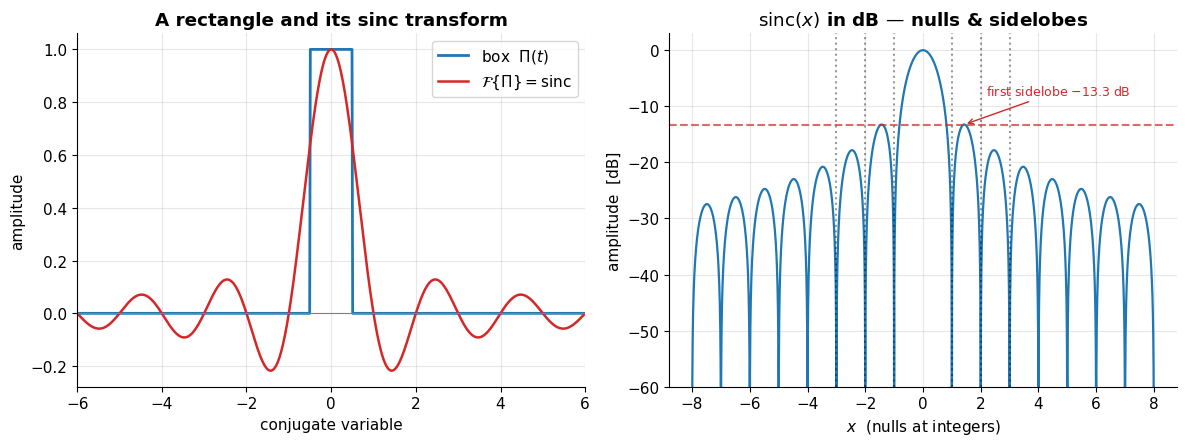

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))

# Left: the box and its sinc transform (linear amplitude).
ax1.plot(t, box, color="#1f77b4", lw=2, label=r"box  $\Pi(t)$")
ax1.plot(freq, analytic, color="#d62728", lw=1.8, label=r"$\mathcal{F}\{\Pi\}=\operatorname{sinc}$")
ax1.axhline(0, color="grey", lw=0.8)
ax1.set_xlim(-6, 6)
ax1.set_xlabel("conjugate variable")
ax1.set_ylabel("amplitude")
ax1.set_title("A rectangle and its sinc transform")
ax1.legend(loc="upper right")

# Right: |sinc| in dB, sidelobes on show.
xx = np.linspace(-8, 8, 4001)
ax2.plot(xx, 20 * np.log10(np.clip(np.abs(np.sinc(xx)), 1e-4, None)), color="#1f77b4", lw=1.6)
for n in (1, 2, 3):
    for sign in (-1, 1):
        ax2.axvline(sign * n, color="k", ls=":", alpha=0.4)
ax2.axhline(-13.26, color="#d62728", ls="--", alpha=0.7)
ax2.annotate(
    r"first sidelobe $-13.3$ dB",
    xy=(1.43, -13.26),
    xytext=(2.2, -8),
    fontsize=9,
    color="#d62728",
    arrowprops=dict(arrowstyle="->", color="#d62728"),
)
ax2.set_ylim(-60, 3)
ax2.set_xlabel(r"$x$  (nulls at integers)")
ax2.set_ylabel("amplitude  [dB]")
ax2.set_title(r"$\operatorname{sinc}(x)$ in dB — nulls & sidelobes")

plt.tight_layout()
plt.show()

The first null sits at $x = 1$ and the sidelobes peak at $-13.3$ dB (in *amplitude*;
$-26.5$ dB in power). That $-13.3$ dB number is the price of a hard rectangular cut —
and the whole point of **window functions** (§6) is to soften the cut and push those
sidelobes down. When you read a spectrum out of a finite stretch of data in
**Maths Lab A (Ch 31)**, the implicit rectangular window convolves your spectrum with
exactly this sinc; the same sinc is the diffraction pattern of a uniformly lit 1-D
slit. One function, two stories.

## 3 · The Gaussian

$$
g(\theta) = \exp\!\left[-\frac{\theta^2}{2\sigma^2}\right].
$$

The Gaussian is special for two reasons. First, the **Fourier transform of a
Gaussian is again a Gaussian** — and it has *no sidelobes*, which makes it the
natural "clean" shape to aim for. Second, the **central limit theorem** makes it the
universal shape of thermal noise (Maths Lab / Ch 3).

In radio astronomy the Gaussian is the standard analytic stand-in for a telescope's
main lobe, with its width quoted as the **full width at half maximum (FWHM)** rather
than $\sigma$. The exact conversion — the very line inside
`jansky.signals.gaussian_beam` — is

$$
\boxed{\ \text{FWHM} = 2\sqrt{2\ln 2}\,\sigma \approx 2.3548\,\sigma\ }
$$

which follows from solving $g(\theta) = \tfrac12$ for $\theta$:
$\exp[-\theta^2/2\sigma^2] = \tfrac12 \Rightarrow \theta_{1/2} = \sigma\sqrt{2\ln 2}$,
and the FWHM is twice that. Let us verify it against the helper.

In [5]:
fwhm = 1.0  # work in units of the FWHM itself
sigma = fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))
print(f"FWHM -> sigma factor 2*sqrt(2 ln 2) = {2 * np.sqrt(2 * np.log(2)):.6f}")
print(f"for FWHM = {fwhm}, sigma = {sigma:.6f}")

theta = np.linspace(-3, 3, 4001)
beam = signals.gaussian_beam(theta, fwhm)

# The helper must equal exp(-theta^2 / 2 sigma^2) and pass through 0.5 at +/- FWHM/2.
ref = np.exp(-0.5 * (theta / sigma) ** 2)
print(f"max |gaussian_beam - exp(-theta^2/2 sigma^2)| = {np.max(np.abs(beam - ref)):.2e}")

half = signals.gaussian_beam(np.array([fwhm / 2]), fwhm)[0]
print(f"gaussian_beam(FWHM/2) = {half:.6f}  (should be exactly 0.5)")
assert np.isclose(half, 0.5, atol=1e-9)

FWHM -> sigma factor 2*sqrt(2 ln 2) = 2.354820
for FWHM = 1.0, sigma = 0.424661
max |gaussian_beam - exp(-theta^2/2 sigma^2)| = 0.00e+00
gaussian_beam(FWHM/2) = 0.500000  (should be exactly 0.5)


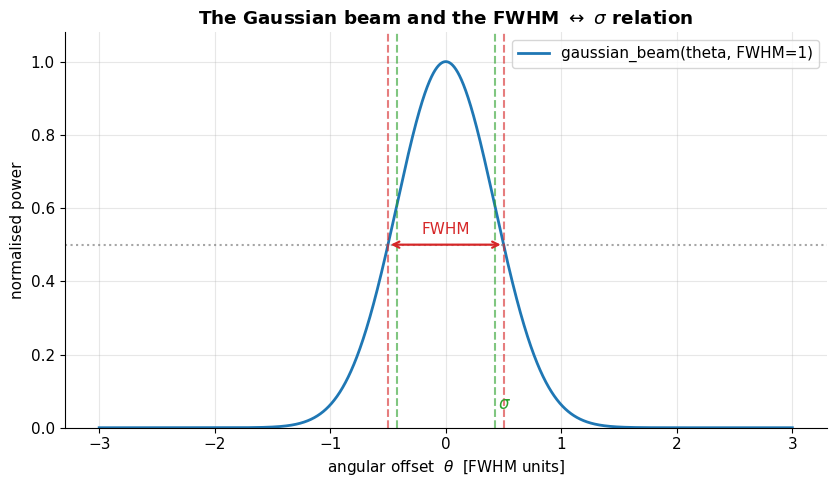

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(theta, beam, color="#1f77b4", lw=2, label="gaussian_beam(theta, FWHM=1)")

# Mark the half-maximum level and the FWHM span.
ax.axhline(0.5, color="grey", ls=":", alpha=0.7)
ax.annotate(
    "",
    xy=(-fwhm / 2, 0.5),
    xytext=(fwhm / 2, 0.5),
    arrowprops=dict(arrowstyle="<->", color="#d62728", lw=1.6),
)
ax.text(0, 0.53, "FWHM", ha="center", color="#d62728", fontsize=11)
for s in (-1, 1):
    ax.axvline(s * fwhm / 2, color="#d62728", ls="--", alpha=0.6)
    ax.axvline(s * sigma, color="#2ca02c", ls="--", alpha=0.6)
ax.text(sigma + 0.03, 0.05, r"$\sigma$", color="#2ca02c", fontsize=12)

ax.set_xlabel(r"angular offset  $\theta$  [FWHM units]")
ax.set_ylabel("normalised power")
ax.set_title(r"The Gaussian beam and the FWHM $\leftrightarrow\ \sigma$ relation")
ax.set_ylim(0, 1.08)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Why this matters downstream.** Real dishes are *tapered* — they illuminate the
aperture more strongly in the centre than at the edges — which suppresses the Airy
sidelobes and rounds the main lobe toward a Gaussian. So a Gaussian of the right
FWHM is an excellent, sidelobe-free model of a single-dish main beam (we overlaid one
on the Airy pattern back in [Chapter 4](04_antennas_and_receivers.ipynb)). The same
shape returns in **[Chapter 9](09_deconvolution_clean.ipynb)** as the **clean beam**:
after CLEAN finds the source components, it restores them by convolving with a
Gaussian fitted to the central lobe of the dirty beam — trading the dirty beam's ugly
sidelobes for a Gaussian's clean ones.

## 4 · The Airy pattern & Bessel $J_1$

A uniformly illuminated *circular* dish does **not** produce a sinc — the 2-D
circular geometry replaces $\sin$ with the first-order **Bessel function** $J_1$,
giving the **Airy pattern**:

$$
P(\theta) = \left[\frac{2 J_1(x)}{x}\right]^2,
\qquad x = \frac{\pi D}{\lambda}\sin\theta .
$$

This is exactly `jansky.signals.airy_beam`. Two landmarks define it:

- the **first null** is where $J_1(x) = 0$ first, at $x = 3.8317$. Setting
  $\pi D \sin\theta/\lambda = 3.8317$ and using the small-angle approximation gives
  $\theta_\text{null} = (3.8317/\pi)\,\lambda/D = 1.2197\,\lambda/D \approx
  1.22\,\lambda/D$ — the **diffraction-limited resolution** of [Chapter 4](04_antennas_and_receivers.ipynb);
- the **first sidelobe** peaks at $-17.6$ dB below the main lobe. That is *higher*
  (leakier) than the sinc's first power sidelobe at $-26.5$ dB — the circular
  aperture's price, and the leakage the antenna engineer fights with tapering (§3, §6).

`scipy.special.jn_zeros(1, k)` hands us the zeros of $J_1$ directly, so we can verify
the $1.22$ factor instead of taking it on faith.

In [7]:
# First few zeros of J1; the first one fixes the 1.22 factor.
zeros = special.jn_zeros(1, 3)
print("first three zeros of J1:", np.round(zeros, 4))
print(f"1.22 factor = x1 / pi  = {zeros[0] / np.pi:.4f}")
assert np.isclose(zeros[0] / np.pi, 1.2197, atol=1e-3)

# First sidelobe peak: search between the first two nulls of the *power* pattern.
x = np.linspace(zeros[0] + 1e-3, zeros[1] - 1e-3, 20001)
side = (2 * special.j1(x) / x) ** 2
x_peak = x[np.argmax(side)]
peak_db = 10 * np.log10(side.max())
print(f"first sidelobe peak at x = {x_peak:.3f}, level = {peak_db:.2f} dB  (textbook -17.6 dB)")
assert np.isclose(peak_db, -17.6, atol=0.2)

first three zeros of J1: [ 3.8317  7.0156 10.1735]
1.22 factor = x1 / pi  = 1.2197
first sidelobe peak at x = 5.136, level = -17.57 dB  (textbook -17.6 dB)


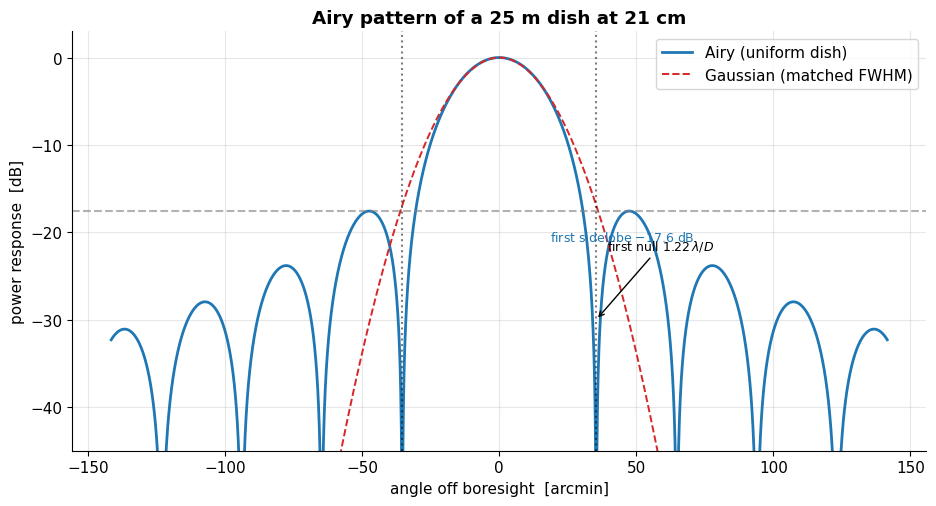

In [8]:
# A concrete dish so the angle axis is physical: 25 m at the 21 cm HI line.
D = 25.0  # metres
wavelength = 0.211  # metres (~1.42 GHz)
theta_null = 1.2197 * wavelength / D  # radians, small-angle
theta = np.linspace(-4 * theta_null, 4 * theta_null, 4000)

airy = signals.airy_beam(theta, D, wavelength)
# Matched Gaussian: the Airy main lobe has FWHM ~ 1.029 lambda/D.
gauss = signals.gaussian_beam(theta, 1.029 * wavelength / D)

theta_arcmin = np.degrees(theta) * 60.0

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.plot(theta_arcmin, to_db(airy), color="#1f77b4", lw=2, label="Airy (uniform dish)")
ax.plot(
    theta_arcmin, to_db(gauss), color="#d62728", lw=1.4, ls="--", label="Gaussian (matched FWHM)"
)

null_arcmin = np.degrees(theta_null) * 60.0
for s in (-1, 1):
    ax.axvline(s * null_arcmin, color="k", ls=":", alpha=0.5)
ax.axhline(-17.6, color="grey", ls="--", alpha=0.6)
ax.annotate(
    r"first null $1.22\,\lambda/D$",
    xy=(null_arcmin, -30),
    xytext=(null_arcmin + 4, -22),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="k"),
)
ax.annotate(
    r"first sidelobe $-17.6$ dB",
    xy=(0, -17.6),
    xytext=(0.56, 0.5),
    textcoords="axes fraction",
    fontsize=9,
    color="#1f77b4",
)

ax.set_xlabel("angle off boresight  [arcmin]")
ax.set_ylabel("power response  [dB]")
ax.set_title(f"Airy pattern of a {D:.0f} m dish at {wavelength * 100:.0f} cm")
ax.set_ylim(-45, 3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

The Airy pattern is the *circular-aperture sibling* of the sinc: same idea (Fourier
transform of a uniformly lit aperture), different geometry (a disc instead of a slit),
so $\sin$ becomes $J_1$ and the first null moves from $1.0\,\lambda/D$ to
$1.22\,\lambda/D$. Everything in [Chapter 4](04_antennas_and_receivers.ipynb) about
resolution and sidelobes flows from these two numbers. Note that the matched Gaussian
(dashed) tracks the main lobe well but is *blind to the rings* — exactly why it is a
convenient, but optimistic, beam model.

## 5 · The power law

$$
S(\nu) = A\left(\frac{\nu}{\nu_0}\right)^{\alpha}.
$$

The workhorse spectral shape, implemented as `jansky.signals.power_law`. The exponent
$\alpha$ is the **spectral index**: synchrotron sources have steep, negative indices
($\alpha \approx -0.7$); thermal (free–free) sources are flatter
($\alpha \approx -0.1$ to $+2$). On **log–log axes** a power law is a *straight line
of slope $\alpha$*, because

$$
\log S = \log A + \alpha\,\log(\nu/\nu_0),
$$

so reading a slope off a log–log spectrum is reading off physics — which is how you
measured a spectral index in [Chapter 2](02_physics_of_radio_emission.ipynb). The same
algebra is the **scale-free / $1/f$** idea: a process whose power spectrum is
$P(f)\propto f^{-1}$ has no preferred scale, looking statistically the same whether
you zoom in or out. Power-law noise (flicker / red noise) haunts real receivers for
exactly this reason.

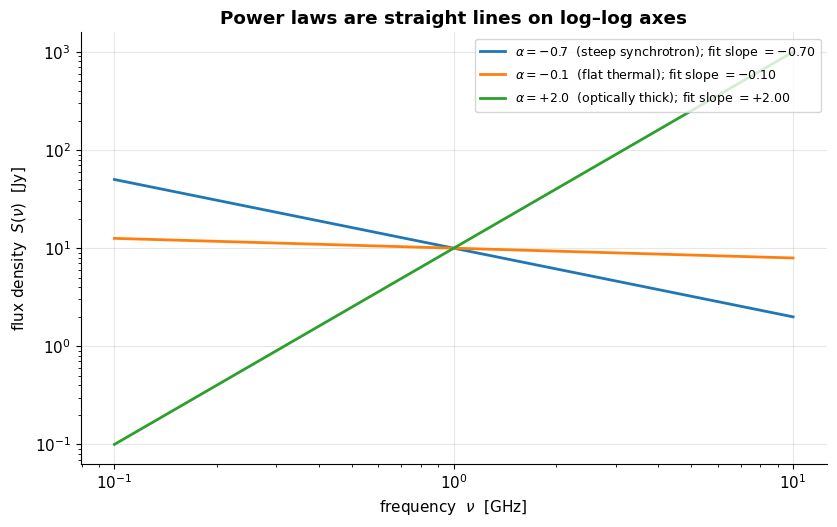

Each fitted slope equals its injected spectral index alpha exactly.


In [9]:
nu = np.logspace(8, 10, 200)  # 0.1 -> 10 GHz
ref = 1e9  # reference at 1 GHz
indices = {-0.7: "steep synchrotron", -0.1: "flat thermal", +2.0: "optically thick"}

fig, ax = plt.subplots(figsize=(8.5, 5.4))
for alpha, label in indices.items():
    S = signals.power_law(nu, amplitude=10.0, spectral_index=alpha, reference=ref)
    # Recover the slope from a straight-line fit in log-log -> should equal alpha.
    slope = np.polyfit(np.log10(nu), np.log10(S), 1)[0]
    ax.loglog(
        nu / 1e9, S, lw=2, label=rf"$\alpha={alpha:+.1f}$  ({label}); fit slope $={slope:+.2f}$"
    )
    assert np.isclose(slope, alpha, atol=1e-6)

ax.set_xlabel(r"frequency  $\nu$  [GHz]")
ax.set_ylabel(r"flux density  $S(\nu)$  [Jy]")
ax.set_title(r"Power laws are straight lines on log–log axes")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

print("Each fitted slope equals its injected spectral index alpha exactly.")

The fitted slope of each line *equals* the spectral index that generated it — that
exact correspondence is what makes log–log spectral fitting (Ch 2) work. Steeper
(more negative) $\alpha$ falls off faster with frequency; the optically-thick
$\alpha=+2$ Rayleigh–Jeans tail *rises*. Same one-parameter family, very different
physics.

## 6 · Window functions (quick reference)

Reading a spectrum from a finite stretch of data multiplies it by a **window**. The
default — doing nothing — is a **rectangular** window, whose transform is the sinc of
§2 with its $-13.3$ dB sidelobes (heavy spectral leakage). Tapering the window's edges
trades a *wider main lobe* for *lower sidelobes*. This is the central trade-off of
**Maths Lab A (Ch 31)**; here we tabulate the common windows from
`scipy.signal.windows` so you have the numbers in one place.

For each window we report:

- **main-lobe width** — the width of the central peak of its transform, in DFT bins
  (full width to the first nulls; bigger = poorer frequency resolution);
- **peak sidelobe** — the highest sidelobe level in dB (more negative = less leakage).

In [10]:
def window_metrics(w, oversample=64):
    # Main-lobe full-null width (in bins) and peak sidelobe level (dB) of a window.
    n = w.size
    W = np.abs(np.fft.rfft(w, n * oversample))
    W /= W.max()
    Wdb = 20 * np.log10(np.clip(W, 1e-12, None))
    # First null: first local minimum after the main lobe.
    falling = np.where(np.diff(Wdb) > 0)[0]
    first_null = falling[0] if falling.size else len(Wdb) - 1
    half_width_bins = first_null / oversample  # 0 -> first null, in bins
    peak_sidelobe = Wdb[first_null:].max()
    return 2 * half_width_bins, peak_sidelobe  # full main-lobe width


N = 64
window_funcs = {
    "Rectangular": windows.boxcar(N),
    "Hann": windows.hann(N, sym=False),
    "Hamming": windows.hamming(N, sym=False),
    "Blackman": windows.blackman(N, sym=False),
}

print(f"{'window':<12} {'main-lobe [bins]':>17} {'peak sidelobe [dB]':>20}")
print("-" * 51)
metrics = {}
for name, w in window_funcs.items():
    mlw, psl = window_metrics(w)
    metrics[name] = (mlw, psl)
    print(f"{name:<12} {mlw:>17.1f} {psl:>20.1f}")

window        main-lobe [bins]   peak sidelobe [dB]
---------------------------------------------------
Rectangular                2.0                -13.3
Hann                       4.0                -31.5
Hamming                    4.0                -42.4
Blackman                   6.0                -58.1


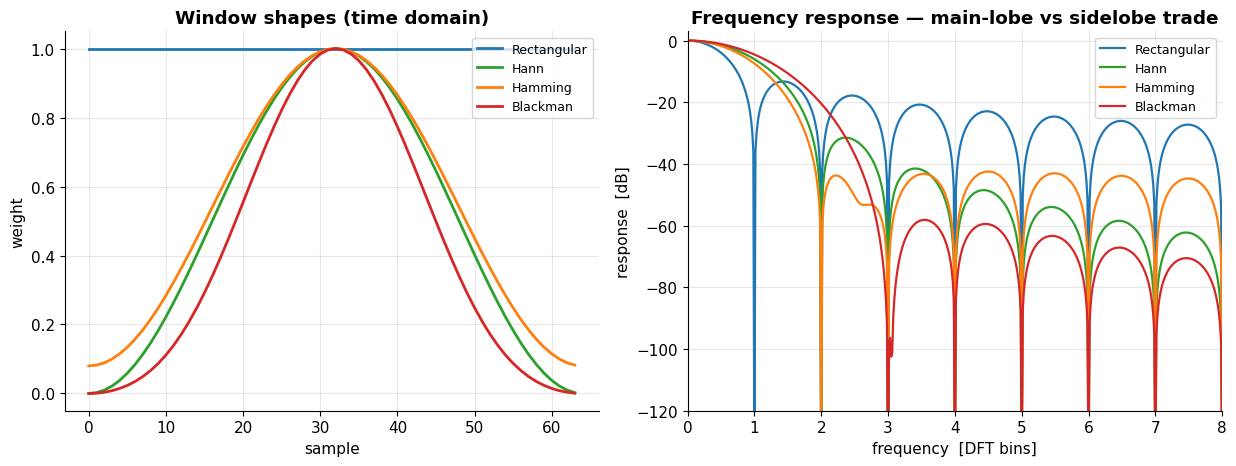

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8))
colors = {"Rectangular": "#1f77b4", "Hann": "#2ca02c", "Hamming": "#ff7f0e", "Blackman": "#d62728"}

# Left: the windows in the time domain.
for name, w in window_funcs.items():
    ax1.plot(np.arange(N), w, lw=2, color=colors[name], label=name)
ax1.set_xlabel("sample")
ax1.set_ylabel("weight")
ax1.set_title("Window shapes (time domain)")
ax1.legend(loc="upper right", fontsize=9)

# Right: their frequency responses in dB (the sidelobe trade-off).
osf = 64
bins = np.fft.rfftfreq(N * osf) * N  # frequency axis in DFT bins
for name, w in window_funcs.items():
    W = np.abs(np.fft.rfft(w, N * osf))
    W /= W.max()
    ax2.plot(bins, 20 * np.log10(np.clip(W, 1e-7, None)), lw=1.6, color=colors[name], label=name)
ax2.set_xlim(0, 8)
ax2.set_ylim(-120, 3)
ax2.set_xlabel("frequency  [DFT bins]")
ax2.set_ylabel("response  [dB]")
ax2.set_title("Frequency response — main-lobe vs sidelobe trade")
ax2.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

Read the table and the right-hand panel together. The **rectangular** window has the
narrowest main lobe (best resolution) but the worst sidelobes ($-13.3$ dB — the sinc
of §2). Each taper — **Hann**, **Hamming**, **Blackman** — widens the main lobe but
buries the sidelobes far deeper (Blackman past $-58$ dB). There is no free lunch:
**resolution versus leakage** is a dial you set per measurement. This is exactly the
choice you make in **Maths Lab A (Ch 31)** when you window a time series before its
FFT.

## Try it yourself

These build directly on the helpers above. Each cell runs as a **scaffold** (it
prints a clear "not implemented" note and returns a placeholder), so the notebook
executes end-to-end before you start. Replace the `# TODO` lines with real work.

In [12]:
# Exercise 1 — Verify the sinc <-> rectangle pair the other way round.
#   The FT of a sinc is a rectangle. Build a sinc, FFT it, and check you recover a box.
def exercise_sinc_roundtrip():
    # TODO: make x = np.linspace(-50, 50, 8192); y = np.sinc(x)
    # TODO: take np.fft.fftshift(np.fft.fft(np.fft.ifftshift(y))) and inspect |.|
    # TODO: confirm the magnitude is ~flat (a box) out to the sinc's bandwidth, ~0 beyond.
    print("exercise_sinc_roundtrip: not implemented yet — returning a placeholder.")
    return None


exercise_sinc_roundtrip()

exercise_sinc_roundtrip: not implemented yet — returning a placeholder.


<details><summary>Solution</summary>

The Fourier transform is its own inverse up to a flip, so transforming a sinc must give back a rectangle. Build the sinc, take the same centred FFT used in §2, and inspect the magnitude: it is flat (a box) out to the sinc's bandwidth and ~0 beyond.

```python
def exercise_sinc_roundtrip():
    x = np.linspace(-50, 50, 8192)
    y = np.sinc(x)
    mag = np.abs(np.fft.fftshift(np.fft.fft(np.fft.ifftshift(y))))
    mag /= mag.max()
    dx = x[1] - x[0]
    fx = np.fft.fftshift(np.fft.fftfreq(x.size, d=dx))   # conjugate axis
    inband = mag[np.abs(fx) < 0.4].mean()                # inside the box
    outband = mag[np.abs(fx) > 0.7].max()                # outside the box
    print(f"mean magnitude inside  |f|<0.4 : {inband:.3f}  (flat top ~1)")
    print(f"max  magnitude outside |f|>0.7 : {outband:.3f}  (~0)")
    return fx, mag

exercise_sinc_roundtrip()
```

The transform is ~0.92 inside `|f| < 0.4` and ~0.004 outside `|f| > 0.7` — a rectangle of half-width 0.5, the box whose transform was the sinc in §2. The sinc ↔ rectangle pair is symmetric: each is the Fourier transform of the other.

</details>

In [13]:
# Exercise 2 — Resolution at two wavelengths.
#   Using theta_null = 1.22 * lambda / D, compute the first-null resolution (in arcmin)
#   of a 25 m dish at BOTH the 21 cm HI line and at 6 cm, and say which is sharper.
def exercise_resolution():
    D = 25.0  # metres
    # TODO: for lam in (0.211, 0.06):  theta = 1.2197 * lam / D  (radians)
    # TODO: convert to arcmin with np.degrees(theta) * 60 and print each
    # TODO: shorter wavelength -> sharper. State which and by what factor.
    print("exercise_resolution: not implemented yet — returning a placeholder.")
    return None


exercise_resolution()

exercise_resolution: not implemented yet — returning a placeholder.


<details><summary>Solution</summary>

Apply $\theta_\text{null} = 1.2197\,\lambda/D$ at each wavelength (radians), then convert to arcmin with `np.degrees(theta) * 60`. The shorter wavelength gives the smaller (sharper) beam, by the ratio of the two wavelengths.

```python
def exercise_resolution():
    D = 25.0  # metres
    res = {}
    for lam in (0.211, 0.06):
        theta = 1.2197 * lam / D                 # radians
        arcmin = np.degrees(theta) * 60.0
        res[lam] = arcmin
        print(f"lambda = {lam*100:5.1f} cm -> first-null resolution = {arcmin:.2f} arcmin")
    print(f"6 cm is sharper by a factor {res[0.211] / res[0.06]:.2f} (= 0.211 / 0.06)")
    return res

exercise_resolution()
```

The 25 m dish resolves to **35.4 arcmin at 21 cm** but **10.1 arcmin at 6 cm** — sharper by a factor of 3.52, exactly $\lambda_{21}/\lambda_{6}$. Resolution scales linearly with $\lambda/D$, so observing at shorter wavelengths (or with a bigger dish) buys you a tighter beam.

</details>

In [14]:
# Exercise 3 — Spectral index from noisy data.
#   Use signals.power_law to make a spectrum with alpha = -0.8, add a little noise with
#   signals.rng(seed), then recover alpha with a log-log polyfit. How close do you get?
def exercise_spectral_index():
    nu = np.logspace(8, 10, 40)
    # TODO: S_true = signals.power_law(nu, amplitude=5.0, spectral_index=-0.8, reference=1e9)
    # TODO: noise = signals.rng(0).normal(0, 0.05 * S_true, size=nu.size); S = S_true + noise
    # TODO: alpha_fit = np.polyfit(np.log10(nu), np.log10(np.clip(S, 1e-6, None)), 1)[0]
    # TODO: print alpha_fit and compare to -0.8.
    print("exercise_spectral_index: not implemented yet — returning a placeholder.")
    return None


exercise_spectral_index()

exercise_spectral_index: not implemented yet — returning a placeholder.


<details><summary>Solution</summary>

Generate the clean power law with `signals.power_law`, add Gaussian noise scaled to 5 % of the signal using a seeded `signals.rng(0)`, then fit a straight line to the log–log data — the slope recovers the spectral index $\alpha$.

```python
def exercise_spectral_index():
    nu = np.logspace(8, 10, 40)
    S_true = signals.power_law(nu, amplitude=5.0, spectral_index=-0.8, reference=1e9)
    noise = signals.rng(0).normal(0, 0.05 * S_true, size=nu.size)
    S = S_true + noise
    alpha_fit = np.polyfit(np.log10(nu), np.log10(np.clip(S, 1e-6, None)), 1)[0]
    print(f"injected alpha = -0.800,  fitted alpha = {alpha_fit:.3f}")
    return alpha_fit

exercise_spectral_index()
```

With the seed `0`, the fit returns `alpha_fit = -0.797` — within ~0.003 of the injected $-0.8$. A 5 % noise level barely moves the slope because the log–log straight line is averaged over two decades of frequency; this is exactly why spectral-index fitting (Ch 2) is robust.

</details>

## Recap & where these show up

Five shapes, recurring everywhere in the course:

| function | where it comes from | key number | chapter |
|---|---|---|---|
| **sinc** $\sin(\pi x)/\pi x$ | FT of a rectangle / 1-D aperture / boxcar | first null at $1$; sidelobes $-13.3$ dB | windows, Ch 31 |
| **Gaussian** $e^{-\theta^2/2\sigma^2}$ | tapered beam; CLT noise; clean beam | $\text{FWHM}=2\sqrt{2\ln2}\,\sigma$ | Ch 9 |
| **Airy** $[2J_1(x)/x]^2$ | FT of a circular aperture | first null $1.22\,\lambda/D$; sidelobe $-17.6$ dB | Ch 4 |
| **power law** $A(\nu/\nu_0)^\alpha$ | synchrotron / thermal spectra; $1/f$ noise | slope $=\alpha$ on log–log | Ch 2 |
| **windows** | tapering a finite record | main-lobe vs sidelobe trade | Ch 31 |

The thread running through all of them is the **Fourier transform**: the sinc and the
Airy pattern are the transforms of a slit and a disc; window sidelobes are the
transform of a taper; the Gaussian is the one shape that transforms to itself with no
sidelobes at all. Keep this Lab next to:

- **[Chapter 2 — Physics of Radio Emission](02_physics_of_radio_emission.ipynb)** for
  the power law and spectral index;
- **[Chapter 4 — Antennas & Receivers](04_antennas_and_receivers.ipynb)** for the Airy
  beam and $1.22\,\lambda/D$;
- **[Chapter 9 — Deconvolution & CLEAN](09_deconvolution_clean.ipynb)** for the
  Gaussian clean beam;
- **Maths Lab A (Ch 31)** for windows and the sinc as a spectral window;
- and **§8 of the [Mathematical Preliminaries](../docs/math-preliminaries.md)** for the
  prose companion to all of it.

<!-- glossary-footer -->

---

## 📖 Glossary

Terms from this chapter — follow a link to look it up in the [course glossary](../docs/glossary.md):

[Beam](../docs/glossary.md#beam) ·
[CLEAN](../docs/glossary.md#clean) ·
[Deconvolution](../docs/glossary.md#deconvolution) ·
[Dirty beam / dirty image](../docs/glossary.md#dirty-beam-dirty-image) ·
[FWHM](../docs/glossary.md#fwhm) ·
[Sidelobe](../docs/glossary.md#sidelobe) ·
[Spectral index](../docs/glossary.md#spectral-index) ·
[Tapering / weighting](../docs/glossary.md#tapering-weighting)
